# Module 1 — Optimization Basics

## CHE 581 — Process Optimization
### King Saud University · College of Engineering · Department of Chemical Engineering

**Instructor:** Abdulelah S. Alshehri

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

> *"Every engineering design is, at heart, a choice among alternatives. Optimization
> is the discipline of making that choice **rationally** — pinning down what we want,
> what we are allowed to do, and then letting mathematics find the best move."*

This module builds the vocabulary and the core machinery of optimization that the
rest of CHE 581 rests on. We alternate between **concepts** and short **Python
experiments** so that the ideas are not just stated but *seen*.


## Roadmap

**Part 1 — Lecture**
1. What optimization *is*, and why chemical engineers care
2. Anatomy of a problem: variables, objective, constraints, feasible region
3. The standard form and how to massage any model into it
4. Graphical solution of two-variable problems
5. Feasible region and optimality — a worked geometric example
6. Convex sets and convex functions
7. Detecting convexity: the Hessian and its eigenvalues
8. Convexity of feasible regions (level sets)
9. Unconstrained optimization: optimality conditions
10. Analytical example: economic production lot size
11. Analytical example: maximum-likelihood estimation
12. The gradient and the Hessian in many variables
13. Numerical methods I — steepest descent
14. Gradient descent with a fixed step
15. Numerical methods II — Newton's method
16. Quasi-Newton (BFGS) in one breath
17. Application: linear regression (a convex problem)
18. Application: logistic regression (a non-convex flavour)
19. A map of optimization problem types (LP · NLP · MILP · MINLP · under uncertainty)

**Part 2 — Tutorial:** six hands-on exercises with worked solutions.

> **Prerequisite mindset:** comfort with vectors, partial derivatives, and a little
> linear algebra. Everything else we develop as we go.


### Setup

Run this once. It loads the numerical libraries we use throughout and fixes a clean
plotting style.

In [1]:
# @title Environment setup
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
})
print("NumPy", np.__version__, "— ready.")

NumPy 2.4.4 — ready.


# Part 1 — Lecture

## 1. What is optimization, and why do chemical engineers care?

An **optimization problem** asks a single question:

> Among all the choices I am *allowed* to make, which one is *best*?

Making that precise forces us to answer three sub-questions:

| Ingredient | Meaning in a process | Symbol |
|---|---|---|
| What can I adjust? | flowrates, temperatures, reactor volumes, split fractions | the **variables** $x$ |
| How do I score a choice? | cost, profit, yield, energy use, CO$_2$ emitted | the **objective** $f(x)$ |
| What limits me? | mass/energy balances, safety limits, purity specs, non-negativity | the **constraints** $g(x), h(x)$ |

Process engineering is *saturated* with these questions: sizing a heat-exchanger
network for minimum utility cost, choosing operating conditions of a reactor for
maximum selectivity, scheduling a batch plant, fitting a kinetic model to data.
The same handful of mathematical ideas answers all of them — which is exactly why
this first module is worth doing carefully.


## 2. Anatomy of an optimization problem

Let us name the pieces once and for all.

- **Decision variables** $x = (x_1, \dots, x_n)$ — the quantities we are free to set.
- **Objective function** $f(x)$ — the scalar we push up or down. By convention we
  *minimize*; maximizing $f$ is the same as minimizing $-f$, so nothing is lost.
- **Constraints** — relations the variables must respect:
  - *equalities* $h(x) = 0$ (balances, definitions),
  - *inequalities* $g(x) \le 0$ (limits, specs, bounds).
- **Feasible region** $\mathcal{F}$ — the set of *all* points that satisfy every
  constraint simultaneously. Optimization only ever compares points inside $\mathcal{F}$.
- **Optimal solution** $x^\star$ — a feasible point whose objective is at least as
  good as that of every other feasible point.

A useful bookkeeping quantity:

> **Degrees of freedom** $=$ (number of variables) $-$ (number of *independent*
> equality constraints).
>
> For a model $h(x)=0$ with $h:\mathbb{R}^n \to \mathbb{R}^m$ and $n>m$, the degrees
> of freedom equal $n-m$; those are the "knobs" left for optimization to turn. If
> $n \le m$ the equalities already pin the system down and there is nothing to optimize.


## 3. The standard form

Almost every algorithm expects the problem written the same way. We adopt:

$$
\begin{aligned}
\min_{x}\quad & f(x) \\
\text{s.t.}\quad & g(x) \le 0 \\
& h(x) = 0 \\
& x \in X
\end{aligned}
$$

where $X$ collects simple bounds and integrality requirements. Any model can be
folded into this form with a few mechanical rewrites:

- **Maximize $\to$ minimize:** $\;\max f(x) \Longleftrightarrow \min\, -f(x)$.
- **"$\ge$" $\to$ "$\le$":** multiply by $-1$. E.g. $x \ge 0 \Longleftrightarrow -x \le 0$,
  and $x_1 + x_2 \ge 3 \Longleftrightarrow 3 - x_1 - x_2 \le 0$.
- **An equality is two inequalities:**
  $$h(x) = 0 \Longleftrightarrow \begin{cases} h(x) \le 0 \\ -h(x) \le 0 \end{cases}$$
- We use $\le$ and $\ge$, never strict "$<$" or "$>$": a well-posed model should
  attain its optimum, and strict inequalities can leave the feasible set open.

Getting comfortable with these rewrites means you can hand *any* problem to *any*
solver.


## 4. Graphical solution of a two-variable problem

When there are only two (or three) variables we can literally *draw* the problem.
Consider a small production decision:

$$
\begin{aligned}
\max_{x,y}\quad & 40x + 55y &&\text{(profit, SAR/batch)} \\
\text{s.t.}\quad & 4x + 6y \le 48 &&\text{(reactor-hours)} \\
& 3x + 2y \le 24 &&\text{(separation-hours)} \\
& x, y \ge 0
\end{aligned}
$$

Here $x, y$ are the number of batches of two products. Each inequality is a
half-plane; their intersection is the feasible region — a **polygon**. The objective
$40x+55y$ has straight-line *contours* (equal-profit lines); pushing a contour as far
as possible in the improving direction lands us on a **corner** of the polygon.

That last observation is the whole theory of linear programming in a sentence: *for
a linear objective over a polygon, an optimum always sits at a vertex.*


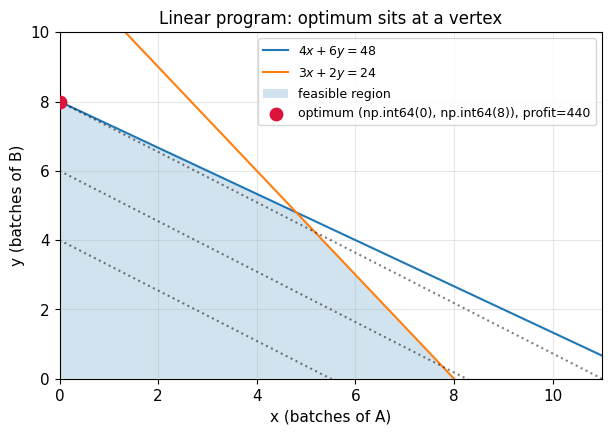

vertex (np.int64(0), np.int64(0))  profit = 0
vertex (np.int64(8), np.int64(0))  profit = 320
vertex (np.int64(6), np.int64(3))  profit = 405
vertex (np.int64(0), np.int64(8))  profit = 440


In [2]:
# @title Draw the feasible region and the optimum
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(0, 12, 400)
c1 = (48 - 4*x) / 6      # 4x + 6y = 48
c2 = (24 - 3*x) / 2      # 3x + 2y = 24

fig, ax = plt.subplots()
ax.plot(x, c1, label=r"$4x+6y=48$")
ax.plot(x, c2, label=r"$3x+2y=24$")

# feasible region = points under BOTH lines, in the first quadrant
yy = np.minimum(c1, c2)
ax.fill_between(x, 0, yy, where=(yy >= 0), alpha=0.20, label="feasible region")

# candidate vertices of the polygon
verts = np.array([[0, 0], [8, 0], [6, 3], [0, 8]])
obj = verts @ np.array([40, 55])
best = verts[np.argmax(obj)]

# a few objective contours (equal-profit lines)  40x+55y = const
for val in [220, 330, 440]:
    ax.plot(x, (val - 40*x)/55, "k:", alpha=0.5)

ax.scatter(*best, color="crimson", zorder=5, s=80,
           label=f"optimum {tuple(best)}, profit={obj.max():.0f}")
ax.set_xlim(0, 11); ax.set_ylim(0, 10)
ax.set_xlabel("x (batches of A)"); ax.set_ylabel("y (batches of B)")
ax.set_title("Linear program: optimum sits at a vertex")
ax.legend(loc="upper right", fontsize=9); plt.show()

for v, o in zip(verts, obj):
    print(f"vertex {tuple(v)!s:8s}  profit = {o:.0f}")

**Reading the picture.** The dotted lines are profit contours; higher profit
lies to the upper-right. The last contour that still touches the shaded region does
so at the vertex $(0,8)$, giving a profit of **440**. Notice how the *inactive*
constraint (separation-hours, which is slack here) does not touch the optimum — a
recurring theme: at the optimum, some constraints press against us (*active*) and
others have room to spare (*inactive*).


## 5. Feasible region and optimality — a geometric example

Linear objectives put optima at corners. Curved objectives can put them anywhere —
on a corner, along an edge, or strictly *inside* the feasible region. Consider
minimizing the squared distance from the point $(2,3)$ subject to a triangular
feasible set:

$$
\begin{aligned}
\min_{x_1,x_2}\quad & (x_1-2)^2 + (x_2-3)^2 \\
\text{s.t.}\quad & x_1 + x_2 \le 5 \\
& x_1 - x_2 \le 1 \\
& x_1, x_2 \ge 0
\end{aligned}
$$

The objective's contours are **concentric circles** centred on $(2,3)$. The
unconstrained minimum $(2,3)$ happens to be feasible (check: $2+3=5\le5$ and
$2-3=-1\le1$), so it *is* the optimum and it sits **on the boundary** where the
constraint $x_1+x_2\le5$ is active. Small changes to the target point would move the
optimum inside or onto a different edge — a good thing to feel in your fingertips.


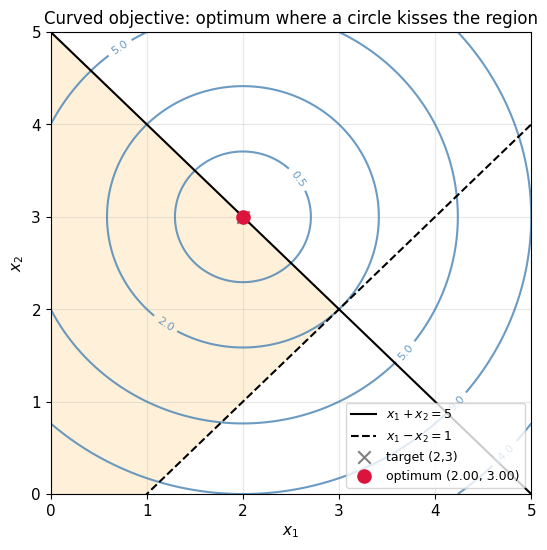

optimum x* = [2. 3.]  objective = 1.4388348017370648e-16


In [3]:
# @title Contours, feasible triangle, and the optimum
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize

f = lambda v: (v[0]-2)**2 + (v[1]-3)**2
cons = [{"type": "ineq", "fun": lambda v: 5 - v[0] - v[1]},
        {"type": "ineq", "fun": lambda v: 1 - (v[0] - v[1])}]
res = minimize(f, [0, 0], bounds=[(0, None), (0, None)], constraints=cons)
xopt = res.x

g1, g2 = np.meshgrid(np.linspace(0, 5, 300), np.linspace(0, 5, 300))
Z = (g1 - 2)**2 + (g2 - 3)**2

fig, ax = plt.subplots(figsize=(6.2, 6))
cs = ax.contour(g1, g2, Z, levels=[0.5, 2, 5, 9, 14], colors="steelblue", alpha=0.8)
ax.clabel(cs, inline=True, fontsize=8)

xx = np.linspace(0, 5, 200)
ax.plot(xx, 5 - xx, "k-", lw=1.5, label=r"$x_1+x_2=5$")
ax.plot(xx, xx - 1, "k--", lw=1.5, label=r"$x_1-x_2=1$")
# shade feasible triangle by masking
feas = (g1 + g2 <= 5) & (g1 - g2 <= 1) & (g1 >= 0) & (g2 >= 0)
ax.contourf(g1, g2, feas.astype(float), levels=[0.5, 1.5], colors=["orange"], alpha=0.15)

ax.scatter(2, 3, marker="x", color="gray", s=80, label="target (2,3)")
ax.scatter(*xopt, color="crimson", s=90, zorder=5,
           label=f"optimum ({xopt[0]:.2f}, {xopt[1]:.2f})")
ax.set_xlim(0, 5); ax.set_ylim(0, 5)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Curved objective: optimum where a circle kisses the region")
ax.legend(loc="lower right", fontsize=9); plt.show()
print("optimum x* =", xopt, " objective =", res.fun)

## 6. Convex sets and convex functions

Convexity is the single most important property in optimization. It is the line
between problems we can solve reliably and problems that can hide surprises.

### Convex *sets*

> A set $C$ is **convex** if, for every pair of points in $C$, the entire straight
> segment joining them also lies in $C$.

Formally, for all $x_1, x_2 \in C$ and every $\theta \in [0,1]$,
$$\theta x_1 + (1-\theta)x_2 \in C.$$

A disk, a filled triangle, a half-plane, a box — all convex. A crescent, a star, an
annulus, a set with a dent or a hole — not convex, because you can find two interior
points whose connecting segment pokes outside.

### Convex *functions*

> A function $f$ is **convex** if, for every pair of points in its domain, the chord
> joining $(x_1, f(x_1))$ and $(x_2, f(x_2))$ lies **on or above** the graph.

Formally, for all $x_1, x_2$ and $\lambda \in [0,1]$,
$$f\big(\lambda x_1 + (1-\lambda)x_2\big) \;\le\; \lambda f(x_1) + (1-\lambda) f(x_2).$$

A function $f$ is **concave** if $-f$ is convex. Convex bowls have a single valley;
that is precisely why a local search can find the *global* minimum. A few facts we
will lean on:

- a non-negative weighted sum of convex functions is convex;
- the pointwise maximum of convex functions is convex;
- every tangent line of a differentiable convex function lies *below* the graph.


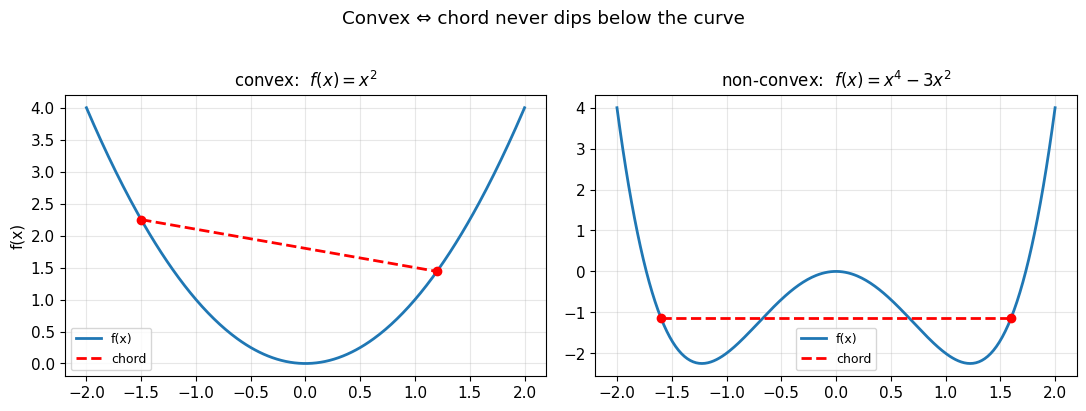

In [4]:
# @title The chord test for convexity (and its failure)
import numpy as np, matplotlib.pyplot as plt

xs = np.linspace(-2, 2, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, fun, a, b) in zip(
        axes,
        [("convex:  $f(x)=x^2$",           lambda t: t**2,             -1.5, 1.2),
         ("non-convex:  $f(x)=x^4-3x^2$",   lambda t: t**4 - 3*t**2,    -1.6, 1.6)]):
    ax.plot(xs, fun(xs), lw=2, label="f(x)")
    lam = np.linspace(0, 1, 50)
    chord_x = (1 - lam)*a + lam*b
    chord_y = (1 - lam)*fun(a) + lam*fun(b)
    ax.plot(chord_x, chord_y, "r--", lw=2, label="chord")
    ax.scatter([a, b], [fun(a), fun(b)], color="red", zorder=5)
    ax.set_title(name); ax.legend(fontsize=9)

axes[0].set_ylabel("f(x)")
plt.suptitle("Convex ⇔ chord never dips below the curve", y=1.02)
plt.tight_layout(); plt.show()

On the left the red chord always stays above the parabola — convex. On the
right the chord dips *below* the curve between the two humps — the tell-tale sign of
non-convexity, and a warning that a local minimum need not be the global one.


In [5]:
# @title Numerical membership test: is a set convex?
import numpy as np

def is_convex_set(indicator, sampler, trials=20000, seed=0):
    '''Empirically test convexity: sample point pairs inside the set and check
       whether random points on the connecting segment stay inside.'''
    rng = np.random.RandomState(seed)
    for _ in range(trials):
        p, q = sampler(rng), sampler(rng)
        t = rng.rand()
        mid = (1 - t)*p + t*q
        if not indicator(mid):
            return False, (p, q, mid)
    return True, None

# Sampler that returns points inside the unit square, then we test two regions.
def square_sampler(rng):
    return rng.uniform(-1, 1, size=2)

disk      = lambda P: P[0]**2 + P[1]**2 <= 1                 # convex
annulus   = lambda P: 0.3 <= P[0]**2 + P[1]**2 <= 1          # NOT convex

# reject-sample points that lie inside each region
def inside_sampler(region):
    def s(rng):
        while True:
            P = rng.uniform(-1, 1, size=2)
            if region(P):
                return P
    return s

for name, region in [("unit disk", disk), ("annulus (ring)", annulus)]:
    ok, witness = is_convex_set(region, inside_sampler(region))
    print(f"{name:15s} convex? {ok}")
    if witness:
        p, q, m = witness
        print(f"    counter-example: segment from {p.round(2)} to {q.round(2)} "
              f"leaves the set at {m.round(2)}")

unit disk       convex? True
annulus (ring)  convex? False
    counter-example: segment from [ 0.14 -0.96] to [0.23 0.89] leaves the set at [0.2 0.3]


## 7. Detecting convexity: the Hessian and its eigenvalues

The chord test is intuitive but impractical for real functions. For a **twice-
differentiable** function there is a clean algebraic criterion.

> A twice-differentiable $f$ is convex **iff** its **Hessian** $H(x)$ — the matrix of
> second partial derivatives — is **positive semidefinite for all $x$**.

Two equivalent ways to check that a symmetric matrix $H$ is positive semidefinite (PSD):

- $v^\top H v \ge 0$ for every non-zero vector $v$; or
- every eigenvalue of $H$ is $\ge 0$.

The full dictionary linking curvature to function shape:

| $f$ is | $H$ is | eigenvalues of $H$ |
|---|---|---|
| strictly convex | positive definite | all $> 0$ |
| convex | positive semidefinite | all $\ge 0$ |
| concave | negative semidefinite | all $\le 0$ |
| strictly concave | negative definite | all $< 0$ |
| neither (saddle) | indefinite | mixed signs |

Let us test three functions symbolically.


In [6]:
# @title Convexity by Hessian eigenvalues (SymPy)
import sympy as sp

x1, x2 = sp.symbols("x1 x2", real=True)

def classify(expr):
    H = sp.hessian(expr, (x1, x2))
    eig = [sp.nsimplify(e) for e in H.eigenvals().keys()]
    vals = sorted(float(e) for e in H.eigenvals().keys())
    if all(v > 1e-9 for v in vals):     verdict = "strictly convex"
    elif all(v >= -1e-9 for v in vals): verdict = "convex"
    elif all(v < -1e-9 for v in vals):  verdict = "strictly concave"
    elif all(v <= 1e-9 for v in vals):  verdict = "concave"
    else:                               verdict = "non-convex (saddle)"
    return H, eig, vals, verdict

examples = {
    "f = 3x1^2 + 2 x1 x2 + 2 x2^2 - x1": 3*x1**2 + 2*x1*x2 + 2*x2**2 - x1,
    "f = x1^2 - 4 x1 x2 + x2^2":          x1**2 - 4*x1*x2 + x2**2,
    "f = -(x1^2 + x2^2)":                 -(x1**2 + x2**2),
}
for name, expr in examples.items():
    H, eig, vals, verdict = classify(expr)
    print(f"{name}")
    print(f"    H = {H.tolist()},  eigenvalues ≈ {np.round(vals,3)}  →  {verdict}\n")

f = 3x1^2 + 2 x1 x2 + 2 x2^2 - x1
    H = [[6, 2], [2, 4]],  eigenvalues ≈ [2.764 7.236]  →  strictly convex

f = x1^2 - 4 x1 x2 + x2^2
    H = [[2, -4], [-4, 2]],  eigenvalues ≈ [-2.  6.]  →  non-convex (saddle)

f = -(x1^2 + x2^2)
    H = [[-2, 0], [0, -2]],  eigenvalues ≈ [-2.]  →  strictly concave



Notice the middle example: the coefficient on the cross term is large enough
to drag one eigenvalue negative, producing a **saddle** even though both pure
second derivatives are positive. Convexity is a statement about the *whole* Hessian,
not about the diagonal alone.


## 8. Convexity of feasible regions

Convex *functions* are what we minimize; convex *sets* are the regions we minimize
over. They are linked through **level sets**:

> If $g(x)$ is convex, then the lower level set $\{x : g(x) \le \alpha\}$ is a convex
> set.

That is why writing constraints as $g(x) \le 0$ with $g$ convex guarantees a convex
feasible region — and the **intersection of convex sets is convex**, so stacking many
such constraints keeps the region convex. (The *upper* level set $\{x : g(x)\ge\alpha\}$
of a convex $g$ need not be convex, which is why the direction of the inequality
matters.)

A quick classification for a single equality $h(x)=0$:

- If $h$ is **linear/affine**, it is both convex and concave, so $h(x)=0$ describes a
  **convex** region (a line, plane, or hyperplane).
- If $h$ is **nonlinear**, $h(x)=0$ generally describes a **non-convex** region.

**Worked check.** Is the region $-e^{2x-3} - x^2 \ge -10$ convex? Rewrite it as
$g(x) = e^{2x-3} + x^2 - 10 \le 0$ and test $g$: since $g''(x) = 4e^{2x-3} + 2 > 0$
everywhere, $g$ is convex, so its lower level set — the feasible region — is convex.


min of g''(x) over the range: 2.000066806803161  → convex


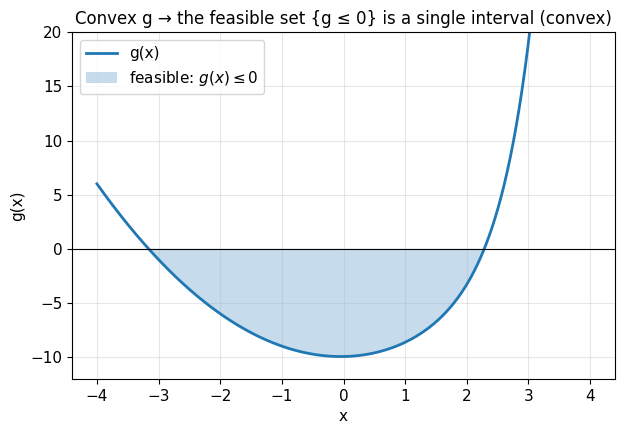

In [7]:
# @title Level set of a convex constraint is convex
import numpy as np, matplotlib.pyplot as plt

g = lambda x: np.exp(2*x - 3) + x**2 - 10       # convex in x

x = np.linspace(-4, 4, 500)
gp2 = 4*np.exp(2*x - 3) + 2                       # second derivative > 0 everywhere
print("min of g''(x) over the range:", gp2.min(), " → convex" )

fig, ax = plt.subplots()
ax.plot(x, g(x), lw=2, label="g(x)")
ax.axhline(0, color="k", lw=0.8)
feas = g(x) <= 0
ax.fill_between(x, g(x), 0, where=feas, alpha=0.25, label=r"feasible: $g(x)\leq 0$")
ax.set_ylim(-12, 20); ax.set_xlabel("x"); ax.set_ylabel("g(x)")
ax.set_title("Convex g → the feasible set {g ≤ 0} is a single interval (convex)")
ax.legend(); plt.show()

## 9. Unconstrained optimization: optimality conditions

Strip away the constraints and we are left with

$$\min_{x \in \mathbb{R}^n} f(x), \qquad f \text{ twice differentiable.}$$

Two conditions pin down a local minimum $x^\star$:

- **Necessary (first-order):** the gradient vanishes,
  $$\nabla f(x^\star) = 0 \quad\text{(a "stationary point").}$$
- **Sufficient (second-order):** the Hessian is positive definite there,
  $$\nabla^2 f(x^\star) \succ 0 \quad\Longleftrightarrow\quad \text{all eigenvalues} > 0.$$

A stationary point can be a minimum, a maximum, or a saddle — the Hessian tells them
apart. And the payoff of convexity:

> **Theorem.** If $f$ is strictly convex and has a stationary point $x^\star$, then
> $x^\star$ is the *unique* local — and therefore global — minimum.

For a convex problem, "solve $\nabla f = 0$" is not just a candidate step; it *is* the
answer.


## 10. Analytical example: economic production lot size

A plant must supply $D = 200{,}000$ tonnes per year of a chemical. Production runs in
**lots** of size $Q$ (tonnes per run). Two costs compete:

- **Holding cost.** On average half a lot sits in inventory, costing
  $C_h = 8$ SAR per tonne per year to store: holding $= C_h \cdot Q/2$.
- **Setup cost.** Each run incurs a fixed changeover cost $C_s = 1500$ SAR,
  regardless of lot size. With $D/Q$ runs per year: setup $= C_s \cdot D/Q$.

Total annual cost:
$$\text{TC}(Q) = \frac{C_h}{2}\,Q + \frac{C_s D}{Q}, \qquad Q > 0.$$

The first term rises with $Q$, the second falls — a classic trade-off. Setting the
derivative to zero,
$$\frac{d\,\text{TC}}{dQ} = \frac{C_h}{2} - \frac{C_s D}{Q^2} = 0
\;\Longrightarrow\; Q^\star = \sqrt{\frac{2 C_s D}{C_h}},$$
the celebrated **Economic Order/Production Quantity**. The second derivative
$\text{TC}''(Q) = 2 C_s D / Q^3 > 0$ confirms a minimum.


Q* = 8,660.3 tonnes per run
minimum total cost = 69,282 SAR/yr
second derivative at Q*: 9.238e-04  (>0 → minimum)


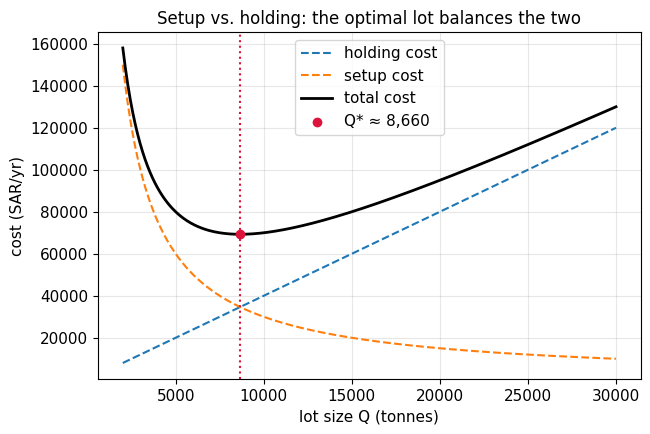

In [8]:
# @title Economic production lot size: analytic optimum + curve
import numpy as np, matplotlib.pyplot as plt

D, Ch, Cs = 200_000.0, 8.0, 1500.0
TC   = lambda Q: 0.5*Ch*Q + Cs*D/Q
Qstar = np.sqrt(2*Cs*D/Ch)
print(f"Q* = {Qstar:,.1f} tonnes per run")
print(f"minimum total cost = {TC(Qstar):,.0f} SAR/yr")
print(f"second derivative at Q*: {2*Cs*D/Qstar**3:.3e}  (>0 → minimum)")

Q = np.linspace(2000, 30000, 400)
fig, ax = plt.subplots()
ax.plot(Q, 0.5*Ch*Q,   "--", label="holding cost")
ax.plot(Q, Cs*D/Q,     "--", label="setup cost")
ax.plot(Q, TC(Q), lw=2, color="black", label="total cost")
ax.axvline(Qstar, color="crimson", ls=":")
ax.scatter([Qstar], [TC(Qstar)], color="crimson", zorder=5, label=f"Q* ≈ {Qstar:,.0f}")
ax.set_xlabel("lot size Q (tonnes)"); ax.set_ylabel("cost (SAR/yr)")
ax.set_title("Setup vs. holding: the optimal lot balances the two")
ax.legend(); plt.show()

**Extension worth pondering.** Suppose the per-run cost grows with lot size as
$\sqrt{Q}$ instead of being fixed. Then the stationarity condition becomes a
transcendental equation with no tidy closed form — a first taste of *why* we will need
the numerical methods developed later in this module.


## 11. Analytical example: maximum-likelihood estimation

Optimization is the engine of statistical learning. **Maximum-likelihood estimation
(MLE)** chooses model parameters that make the observed data most probable.

Flip a (possibly biased) coin $N = H + T$ times, seeing $H$ heads and $T$ tails. If
$\theta$ is the probability of heads, the likelihood of the data is
$$L(\theta) = \theta^{H}(1-\theta)^{T}.$$

Because $\log$ is monotonically increasing, maximizing $L$ is the same as maximizing
the **log-likelihood**, which turns products into sums:
$$\ell(\theta) = H\log\theta + T\log(1-\theta).$$

Setting $\ell'(\theta) = 0$:
$$\frac{H}{\theta} - \frac{T}{1-\theta} = 0
\;\Longrightarrow\; \hat\theta_{\text{MLE}} = \frac{H}{H+T}.$$

The estimate is simply the observed fraction of heads. (Do check the second-order
condition: $\ell''(\theta) < 0$, so this stationary point is indeed a maximum.)


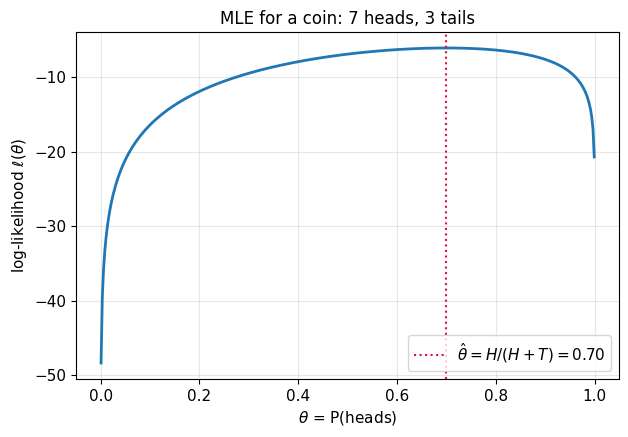

closed-form MLE: 0.7
numerical argmax: 0.699


In [9]:
# @title Coin MLE: the log-likelihood and its peak
import numpy as np, matplotlib.pyplot as plt

H, T = 7, 3
theta = np.linspace(1e-3, 1-1e-3, 400)
loglik = H*np.log(theta) + T*np.log(1 - theta)
theta_hat = H/(H+T)

fig, ax = plt.subplots()
ax.plot(theta, loglik, lw=2)
ax.axvline(theta_hat, color="crimson", ls=":", label=fr"$\hat\theta = H/(H+T) = {theta_hat:.2f}$")
ax.set_xlabel(r"$\theta$ = P(heads)"); ax.set_ylabel(r"log-likelihood $\ell(\theta)$")
ax.set_title(f"MLE for a coin: {H} heads, {T} tails")
ax.legend(); plt.show()
print("closed-form MLE:", theta_hat)
print("numerical argmax:", theta[np.argmax(loglik)].round(3))

## 12. The gradient and the Hessian in many variables

For functions of several variables, first and second derivatives become a **vector**
and a **matrix**.

The **gradient** collects the first partials (it points in the direction of steepest
increase):
$$\nabla f = \left[\frac{\partial f}{\partial x_1},\ \frac{\partial f}{\partial x_2},\ \dots,\ \frac{\partial f}{\partial x_n}\right].$$

The **Hessian** collects the second partials (it encodes curvature):
$$\nabla^2 f =
\begin{bmatrix}
\dfrac{\partial^2 f}{\partial x_1^2} & \cdots & \dfrac{\partial^2 f}{\partial x_1 \partial x_n}\\[2mm]
\vdots & \ddots & \vdots \\[1mm]
\dfrac{\partial^2 f}{\partial x_n \partial x_1} & \cdots & \dfrac{\partial^2 f}{\partial x_n^2}
\end{bmatrix}.$$

Below we compute both symbolically and confirm them with a finite-difference check —
a habit worth keeping when you hand-derive gradients for a solver.


In [10]:
# @title Gradient & Hessian: symbolic vs. finite differences
import sympy as sp, numpy as np

x1, x2, x3 = sp.symbols("x1 x2 x3", real=True)
f_expr = 15*x1 + 2*x2**3 - 3*x1*x3**2

grad_sym = sp.Matrix([f_expr]).jacobian((x1, x2, x3))
hess_sym = sp.hessian(f_expr, (x1, x2, x3))
print("symbolic gradient:", grad_sym.T.tolist())
print("symbolic Hessian :", hess_sym.tolist())

# turn into fast numeric functions and check at a test point
f_num    = sp.lambdify((x1, x2, x3), f_expr, "numpy")
grad_num = sp.lambdify((x1, x2, x3), grad_sym, "numpy")

def fd_grad(fun, p, h=1e-6):
    p = np.asarray(p, float); g = np.zeros_like(p)
    for i in range(len(p)):
        e = np.zeros_like(p); e[i] = h
        g[i] = (fun(*(p+e)) - fun(*(p-e))) / (2*h)
    return g

p = [1.0, 2.0, -1.0]
print("\nat p =", p)
print("analytic grad :", np.array(grad_num(*p)).ravel())
print("finite-diff   :", fd_grad(f_num, p))

symbolic gradient: [[15 - 3*x3**2], [6*x2**2], [-6*x1*x3]]
symbolic Hessian : [[0, 0, -6*x3], [0, 12*x2, 0], [-6*x3, 0, -6*x1]]

at p = [1.0, 2.0, -1.0]
analytic grad : [12. 24.  6.]
finite-diff   : [12. 24.  6.]


## 13. Numerical methods I — steepest descent

Most process models are too tangled to solve $\nabla f = 0$ by hand. Iterative
numerical methods take over. They nearly all share one skeleton:

> pick a **search direction** $d_k$, then take a step of length $\alpha_k$ along it:
> $$x_{k+1} = x_k + \alpha_k d_k.$$

The simplest choice uses the gradient itself. Since $-\nabla f$ points *downhill* most
steeply, **steepest (gradient) descent** sets $d_k = -\nabla f(x_k)$:

$$x_{k+1} = x_k - \alpha_k \nabla f(x_k).$$

**Algorithm.**
1. Choose a start $x_0$; set $k = 0$.
2. Compute the gradient $\nabla f(x_k)$; stop if it is (nearly) zero.
3. Set the direction $d_k = -\nabla f(x_k)$.
4. Choose a step $\alpha_k$ (a 1-D "line search" that minimizes $f$ along $d_k$).
5. Update $x_{k+1} = x_k + \alpha_k d_k$, increment $k$, and repeat.

Each iteration collapses an $n$-dimensional problem into a single 1-D minimization —
elegant, but as we will see, sometimes slow.


steepest descent: 25 iterations
x* (numeric): [ 0.4 -0.2]   x* (exact): [ 0.4 -0.2]


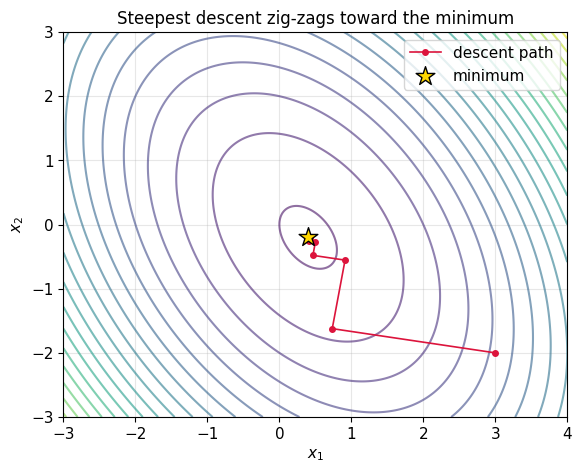

In [11]:
# @title Steepest descent on a quadratic, with the exact line search
import numpy as np, matplotlib.pyplot as plt

# f(x) = 1/2 x^T Q x + b^T x  (convex since Q is positive definite)
Q = np.array([[3.0, 1.0], [1.0, 2.0]])
b = np.array([-1.0, 0.0])
f    = lambda x: 0.5*x @ Q @ x + b @ x
grad = lambda x: Q @ x + b

def steepest_descent(x0, tol=1e-8, maxit=200):
    x = np.array(x0, float); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        alpha = (g @ g) / (g @ Q @ g)     # exact step for a quadratic
        x = x - alpha*g
        path.append(x.copy())
    return x, np.array(path)

xopt, path = steepest_descent([3.0, -2.0])
true = np.linalg.solve(Q, -b)
print(f"steepest descent: {len(path)-1} iterations")
print("x* (numeric):", xopt, "  x* (exact):", true)

# visualise the zig-zag path over the contours
g1, g2 = np.meshgrid(np.linspace(-3, 4, 300), np.linspace(-3, 3, 300))
Z = 0.5*(Q[0,0]*g1**2 + 2*Q[0,1]*g1*g2 + Q[1,1]*g2**2) + b[0]*g1 + b[1]*g2
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.contour(g1, g2, Z, levels=20, cmap="viridis", alpha=0.6)
ax.plot(path[:,0], path[:,1], "o-", color="crimson", ms=4, lw=1.2, label="descent path")
ax.scatter(*true, marker="*", s=200, color="gold", edgecolor="k", zorder=5, label="minimum")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Steepest descent zig-zags toward the minimum")
ax.legend(); plt.show()

Look at the **zig-zag**. Because each step is orthogonal to the last, steepest
descent makes right-angle turns and can crawl through long, narrow valleys. It only
ever uses first-order (gradient) information — cheap per step, but not always
efficient overall.


## 14. Gradient descent with a fixed step

The exact line search above is a luxury. In machine learning we usually replace
$\alpha_k$ by a small **fixed** step size (the *learning rate*):

$$x_{k+1} = x_k - \alpha\, \nabla f(x_k), \qquad \alpha \text{ small and constant.}$$

This is the workhorse behind training neural networks. The catch is choosing
$\alpha$: too small and progress is glacial; too large and the iterates overshoot and
diverge. The experiment below shows both failure modes and the sweet spot.


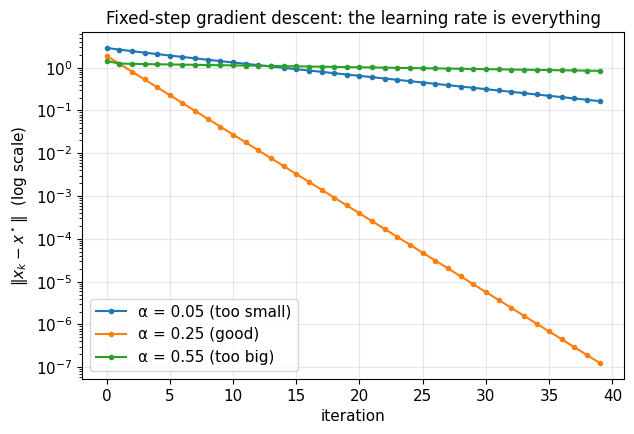

In [12]:
# @title The learning rate matters: small, good, too big
import numpy as np, matplotlib.pyplot as plt

Q = np.array([[3.0, 1.0], [1.0, 2.0]]); b = np.array([-1.0, 0.0])
f    = lambda x: 0.5*x @ Q @ x + b @ x
grad = lambda x: Q @ x + b
true = np.linalg.solve(Q, -b)

def gd_fixed(alpha, x0=(3.0, -2.0), steps=40):
    x = np.array(x0, float); errs = []
    for _ in range(steps):
        x = x - alpha*grad(x)
        errs.append(np.linalg.norm(x - true))
    return errs

fig, ax = plt.subplots()
for alpha, style in [(0.05, "too small"), (0.25, "good"), (0.55, "too big")]:
    errs = gd_fixed(alpha)
    ax.semilogy(errs, "o-", ms=3, label=f"α = {alpha} ({style})")
ax.set_xlabel("iteration"); ax.set_ylabel(r"$\|x_k - x^\star\|$  (log scale)")
ax.set_title("Fixed-step gradient descent: the learning rate is everything")
ax.legend(); plt.show()

## 15. Numerical methods II — Newton's method

Steepest descent ignores curvature. **Newton's method** exploits it. Expand $f$ in a
second-order Taylor series about the current point and minimize that local quadratic
model exactly. Requiring the gradient of the model to vanish gives the update

$$x_{k+1} = x_k - \big[\nabla^2 f(x_k)\big]^{-1}\, \nabla f(x_k).$$

Compared with gradient descent, Newton's method uses *both* the gradient **and** the
Hessian. The consequences:

- On a quadratic (constant Hessian) it lands on the exact minimum in **one step** —
  *quadratic convergence*.
- Near a well-behaved minimum it converges extremely fast (the error roughly squares
  each iteration).
- But each step costs a Hessian evaluation *and* a linear solve, which becomes
  expensive in high dimensions — and if the Hessian is not positive definite the raw
  step can point uphill.

**Algorithm.**
1. Choose $x_0$.
2. Compute $\nabla f(x_k)$ and $\nabla^2 f(x_k)$.
3. Solve $\nabla^2 f(x_k)\, d_k = -\nabla f(x_k)$ and set $x_{k+1} = x_k + d_k$.
4. Check convergence; if not converged, repeat.


In [13]:
# @title Newton vs. steepest descent on the same quadratic
import numpy as np

Q = np.array([[3.0, 1.0], [1.0, 2.0]]); b = np.array([-1.0, 0.0])
grad = lambda x: Q @ x + b
hess = lambda x: Q
true = np.linalg.solve(Q, -b)

def newton(x0, tol=1e-10, maxit=50):
    x = np.array(x0, float); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        d = np.linalg.solve(hess(x), -g)   # Newton direction
        x = x + d
        path.append(x.copy())
    return x, np.array(path)

xopt, path = newton([3.0, -2.0])
print(f"Newton's method: {len(path)-1} iteration(s)")
print("x* =", xopt, "  exact =", true)
print("→ a quadratic is solved in a single Newton step.")

Newton's method: 1 iteration(s)
x* = [ 0.4 -0.2]   exact = [ 0.4 -0.2]
→ a quadratic is solved in a single Newton step.


## 16. Quasi-Newton methods (BFGS) in one breath

Newton is fast but needs the Hessian and its inverse — often too costly or simply
unavailable. **Quasi-Newton** methods keep Newton's spirit while *building an
approximation* of the Hessian from successive gradients, using nothing but first
derivatives.

The most successful recipe is **BFGS** (Broyden–Fletcher–Goldfarb–Shanno). It
maintains a symmetric positive-definite approximation $B_k \approx \nabla^2 f$, updated
at each step from the change in position $s = x_{k+1}-x_k$ and the change in gradient
$y = \nabla f(x_{k+1}) - \nabla f(x_k)$. BFGS gives **superlinear** convergence and is
widely regarded as the best general-purpose method when second derivatives are not on
hand. It is exactly what `scipy.optimize.minimize(method="BFGS")` runs by default.


In [14]:
# @title BFGS via SciPy on a non-quadratic (Rosenbrock) function
import numpy as np
from scipy.optimize import minimize

# The Rosenbrock "banana" — a classic hard test: curved narrow valley, min at (1,1)
rosen  = lambda x: (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2
rosen_g = lambda x: np.array([-2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2),
                               200*(x[1] - x[0]**2)])

for method in ["CG", "BFGS", "Newton-CG"]:
    kwargs = dict(jac=rosen_g)
    if method == "Newton-CG":
        kwargs["hess"] = lambda x: np.array(
            [[2 - 400*(x[1] - 3*x[0]**2), -400*x[0]], [-400*x[0], 200]])
    r = minimize(rosen, [-1.2, 1.0], method=method, **kwargs)
    print(f"{method:10s}  x* = {r.x.round(4)}  f = {r.fun:.2e}  "
          f"iters = {r.nit}  grad-evals = {r.get('njev','?')}")

CG          x* = [1. 1.]  f = 1.88e-14  iters = 36  grad-evals = 77
BFGS        x* = [1. 1.]  f = 2.54e-15  iters = 32  grad-evals = 39
Newton-CG   x* = [1. 1.]  f = 3.03e-10  iters = 83  grad-evals = 105


## 17. Application: linear regression (a convex problem)

Fitting a linear model is optimization in disguise. Given data pairs
$\{(x^{(i)}, y^{(i)})\}_{i=1}^{n}$, we posit
$$\hat y = \theta_0 + \theta_1 x_1 + \dots + \theta_d x_d$$
and choose the parameters $\theta$ that minimize the **mean squared error**:
$$J(\theta) = \frac{1}{n}\sum_{i=1}^{n}\big(\hat y^{(i)} - y^{(i)}\big)^2.$$

$J$ is a **convex quadratic** in $\theta$, so it has a single global minimum with two
equivalent routes to it:

- **Closed form (normal equations).** Stacking the data into $X$ (with a leading
  column of ones) and $Y$, the optimum is
  $$\hat\theta = (X^\top X)^{-1} X^\top Y.$$
  No iteration — but the matrix inverse gets costly and ill-conditioned when the number
  of features $d$ is large.
- **Gradient descent.** Iterate $\theta \leftarrow \theta - \alpha\, \nabla J(\theta)$.
  Scales far better to large, high-dimensional data.

We fit a small chemical-engineering dataset: predicting a building's energy demand
from the indoor–outdoor temperature difference and the number of occupants.


normal equations : [55.341 85.941  5.657]
gradient descent : [55.341 85.941  5.657]
R^2 = 0.738


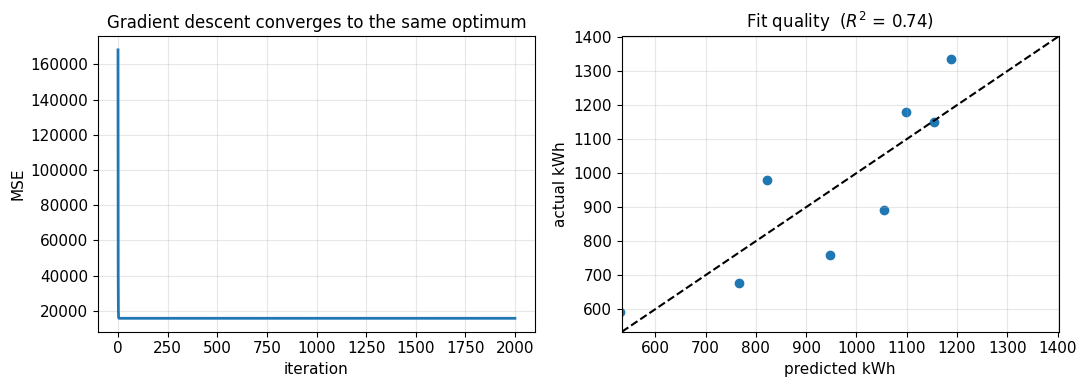

In [15]:
# @title Linear regression: normal equations vs. gradient descent
import numpy as np, matplotlib.pyplot as plt

# --- synthetic building-energy dataset (temperature diff, occupancy) -> kWh ---
temp_diff = np.array([5.4, 7.1, 11.2, 12.4, 8.0, 9.6, 6.3, 10.5])
occupancy = np.array([  2,  18,   30,    6,  55,  12,  40,   25], float)
energy    = np.array([593, 676, 1335, 1149, 892, 760, 980, 1180], float)

X = np.column_stack([np.ones_like(temp_diff), temp_diff, occupancy])
Y = energy

# (1) closed-form normal equations
theta_ne = np.linalg.solve(X.T @ X, X.T @ Y)

# (2) gradient descent on the MSE (features scaled for a well-behaved step)
mu, sd = X[:,1:].mean(0), X[:,1:].std(0)
Xs = np.column_stack([np.ones(len(X)), (X[:,1:] - mu)/sd])
theta_s = np.zeros(3); n = len(Y); alpha = 0.3
history = []
for _ in range(2000):
    grad = (2/n) * Xs.T @ (Xs @ theta_s - Y)
    theta_s = theta_s - alpha*grad
    history.append(np.mean((Xs @ theta_s - Y)**2))
# unscale gradient-descent parameters back to original units
theta_gd = np.array([theta_s[0] - (theta_s[1:]*mu/sd).sum(),
                     *(theta_s[1:]/sd)])

print("normal equations :", theta_ne.round(3))
print("gradient descent :", theta_gd.round(3))
pred = X @ theta_ne
R2 = 1 - np.sum((Y - pred)**2) / np.sum((Y - Y.mean())**2)
print(f"R^2 = {R2:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history, lw=2); ax[0].set_xlabel("iteration"); ax[0].set_ylabel("MSE")
ax[0].set_title("Gradient descent converges to the same optimum")
ax[1].scatter(pred, Y); lims = [Y.min()*0.9, Y.max()*1.05]
ax[1].plot(lims, lims, "k--"); ax[1].set_xlim(lims); ax[1].set_ylim(lims)
ax[1].set_xlabel("predicted kWh"); ax[1].set_ylabel("actual kWh")
ax[1].set_title(f"Fit quality  ($R^2$ = {R2:.2f})")
plt.tight_layout(); plt.show()

## 18. Application: logistic regression (a non-convex flavour)

Not every learning problem is a friendly convex bowl. **Logistic regression** fits a
line that *separates* two classes. With features $x_1, x_2$ and parameters $\theta$,
the model predicts a probability through the sigmoid
$$P(y=1 \mid x) = \sigma(\theta_0 + \theta_1 x_1 + \theta_2 x_2), \qquad
\sigma(z) = \frac{1}{1 + e^{-z}}.$$

We fit $\theta$ by maximizing the log-likelihood — equivalently minimizing the
**cross-entropy** loss. The **decision boundary** is the line where the predicted
probability equals $\tfrac12$, i.e. $\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$.

Two teaching points hide here. First, this loss surface is **not** the tidy paraboloid
of linear regression — non-convex landscapes are the norm in machine learning, and
different starting points or solvers can matter. Second, when the two classes are
**perfectly separable** (as in our tiny dataset), the likelihood keeps improving as
the weights grow without bound, so the raw parameters diverge; a small
**regularization** term tames them. We include one below.


fitted theta: [-2.073  2.987 -4.674]
prediction for new point (x1=7, x2=3): P(Yes) = 0.992 → Yes


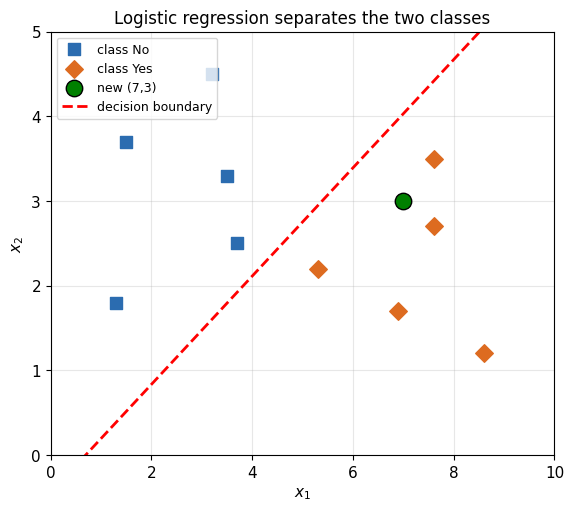

In [16]:
# @title Logistic regression: fit a classifier and draw the boundary
import numpy as np, matplotlib.pyplot as plt

X1 = np.array([3.7, 1.5, 3.2, 1.3, 3.5, 7.6, 5.3, 6.9, 8.6, 7.6])
X2 = np.array([2.5, 3.7, 4.5, 1.8, 3.3, 2.7, 2.2, 1.7, 1.2, 3.5])
y  = np.array([  0,   0,   0,   0,   0,   1,   1,   1,   1,   1])   # No / Yes

X = np.column_stack([np.ones_like(X1), X1, X2])
sigmoid = lambda z: 1/(1 + np.exp(-z))

# Newton's method on the (L2-regularized) cross-entropy loss
theta = np.zeros(3); lam = 1e-2
for _ in range(50):
    p = sigmoid(X @ theta)
    grad = X.T @ (p - y) + lam*theta
    W = p*(1 - p)
    Hn = X.T @ (X * W[:, None]) + lam*np.eye(3)
    theta -= np.linalg.solve(Hn, grad)

print("fitted theta:", theta.round(3))
new = np.array([1, 7, 3])
print(f"prediction for new point (x1=7, x2=3): "
      f"P(Yes) = {sigmoid(theta @ new):.3f} → "
      f"{'Yes' if sigmoid(theta @ new) > 0.5 else 'No'}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(X1[y==0], X2[y==0], marker="s", s=80, label="class No",  color="#2b6cb0")
ax.scatter(X1[y==1], X2[y==1], marker="D", s=80, label="class Yes", color="#dd6b20")
ax.scatter(7, 3, marker="o", s=140, color="green", edgecolor="k", zorder=5, label="new (7,3)")
xb = np.linspace(0, 10, 100)                     # boundary: θ0 + θ1 x1 + θ2 x2 = 0
ax.plot(xb, -(theta[0] + theta[1]*xb)/theta[2], "r--", lw=2, label="decision boundary")
ax.set_xlim(0, 10); ax.set_ylim(0, 5)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Logistic regression separates the two classes")
ax.legend(loc="upper left", fontsize=9); plt.show()

## 19. A map of optimization problem types

Every problem we meet in CHE 581 sits somewhere on this map, and its location dictates
which algorithms apply and how hard it is.

| Class | Variables | Functions | Chemical-engineering flavour |
|---|---|---|---|
| **LP** — Linear Programming | continuous | all linear | blending, transportation, refinery planning |
| **NLP** — Nonlinear Programming | continuous | some nonlinear | reactor optimization, parameter estimation |
| **IP** — Integer Programming | integer | (linear) | yes/no selection, unit counts |
| **MILP** — Mixed-Integer Linear | mixed | linear | scheduling, network/design selection |
| **MINLP** — Mixed-Integer Nonlinear | mixed | some nonlinear | process synthesis, superstructure optimization |

Beyond the deterministic world lies **optimization under uncertainty**, where data are
not known exactly:

- **Stochastic programming** minimizes an *expected* objective $\mathbb{E}_\omega[f(x,\omega)]$
  over probabilistic scenarios;
- **Robust optimization** guards against the *worst case*, $\min_x \max_\omega f(x,\omega)$.

Two properties determine difficulty more than the labels themselves:

1. **Convex vs. non-convex.** Convex problems (LP, and NLPs with convex $f$ and convex
   feasible set) yield a *global* optimum from any local search. Non-convex problems
   (most MINLPs) can trap ordinary methods in a *local* optimum far from the best
   possible — motivating the global-optimization tools we meet later in the course.
2. **Continuous vs. discrete.** Integer variables destroy the smooth landscape that
   gradient methods rely on and generally make problems combinatorially harder.


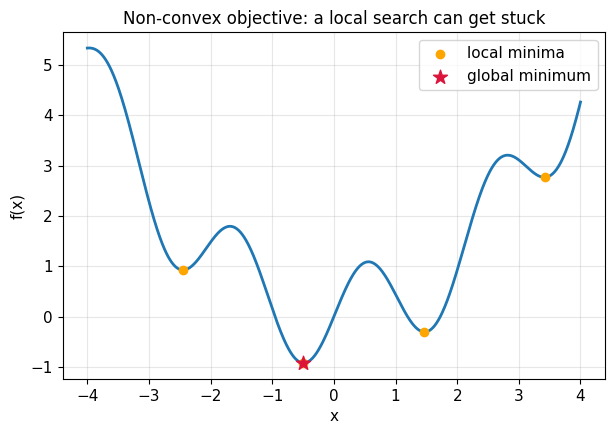

The gradient is zero at EVERY marked point — being stationary is not enough.


In [17]:
# @title Non-convexity in one picture: many local minima
import numpy as np, matplotlib.pyplot as plt

f = lambda x: np.sin(3*x) + 0.3*x**2       # wiggly + gentle bowl
x = np.linspace(-4, 4, 800)

# crude scan for local minima
y = f(x)
loc = np.where((y[1:-1] < y[:-2]) & (y[1:-1] < y[2:]))[0] + 1
gmin = x[np.argmin(y)]

fig, ax = plt.subplots()
ax.plot(x, y, lw=2)
ax.scatter(x[loc], y[loc], color="orange", zorder=5, label="local minima")
ax.scatter(gmin, f(gmin), color="crimson", s=110, marker="*", zorder=6,
           label="global minimum")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_title("Non-convex objective: a local search can get stuck")
ax.legend(); plt.show()
print("The gradient is zero at EVERY marked point — being stationary is not enough.")

# Part 2 — Tutorial (Hands-on)

Work each exercise in the **"Your turn"** cell first; the **"Solution"** cell is there
to check yourself. Learning happens in the struggle, not in the reveal.


## Exercise 1 — Formulate and graph an LP feasible region

A workshop makes two products. Product A needs 2 h of mixing and 1 h of packing;
product B needs 1 h of mixing and 3 h of packing. There are 100 mixing-hours and
90 packing-hours available per week. Profit is 30 SAR per unit of A and 20 SAR per
unit of B.

1. Write the LP in standard form.
2. Plot the feasible region and the profit-maximizing vertex.
3. Report the optimal production plan and profit.


In [18]:
# @title Exercise 1 — Your turn
import numpy as np, matplotlib.pyplot as plt

# TODO: constraints  2A + 1B <= 100 ,  1A + 3B <= 90 ,  A,B >= 0
# TODO: enumerate the polygon vertices and evaluate profit 30A + 20B at each
# TODO: plot the region and mark the best vertex


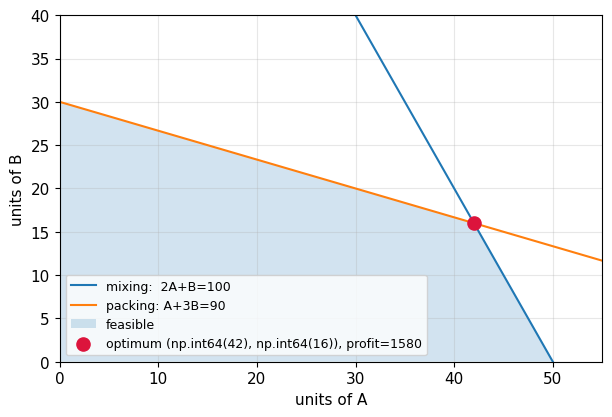

vertex (np.int64(0), np.int64(0)) profit = 0
vertex (np.int64(50), np.int64(0)) profit = 1500
vertex (np.int64(42), np.int64(16)) profit = 1580
vertex (np.int64(0), np.int64(30)) profit = 600

Optimal plan: (np.int64(42), np.int64(16))  → profit 1580 SAR/week


In [19]:
# @title Exercise 1 — Solution
import numpy as np, matplotlib.pyplot as plt

A = np.linspace(0, 55, 300)
mix  = 100 - 2*A            # 2A + B <= 100  → B <= 100 - 2A
pack = (90 - A)/3           # A + 3B <= 90   → B <= (90 - A)/3

# vertices: (0,0), (50,0), intersection, (0,30)
# 2A + B = 100 and A + 3B = 90  → A = 42, B = 16
verts = np.array([[0, 0], [50, 0], [42, 16], [0, 30]])
profit = verts @ np.array([30, 20])
best = verts[np.argmax(profit)]

fig, ax = plt.subplots()
ax.plot(A, mix,  label="mixing:  2A+B=100")
ax.plot(A, pack, label="packing: A+3B=90")
yy = np.minimum(mix, pack)
ax.fill_between(A, 0, yy, where=(yy >= 0), alpha=0.2, label="feasible")
ax.scatter(*best, color="crimson", s=90, zorder=5,
           label=f"optimum {tuple(best)}, profit={profit.max():.0f}")
ax.set_xlim(0, 55); ax.set_ylim(0, 40)
ax.set_xlabel("units of A"); ax.set_ylabel("units of B")
ax.legend(fontsize=9); plt.show()
for v, p in zip(verts, profit):
    print(f"vertex {tuple(v)!s:9s} profit = {p:.0f}")
print("\nOptimal plan:", tuple(best), " → profit", profit.max(), "SAR/week")

## Exercise 2 — Yard fencing (unconstrained reformulation)

You have 80 m of fencing to enclose a rectangular storage yard. What dimensions
maximize the enclosed area?

1. With sides $x$ and $y$, the perimeter constraint is $2x + 2y = 80$. Use it to
   eliminate $y$ and write the area as a function of $x$ **alone** — an *unconstrained*
   problem in one variable.
2. Maximize analytically (first- and second-order conditions).
3. Confirm numerically.


In [20]:
# @title Exercise 2 — Your turn
# Perimeter: 2x + 2y = 80  →  y = 40 - x
# TODO: write A(x) = x*(40 - x); find x* by setting A'(x) = 0; check A''(x) < 0


In [21]:
# @title Exercise 2 — Solution
import numpy as np, sympy as sp

x = sp.symbols("x", positive=True)
A = x*(40 - x)                      # area after eliminating y = 40 - x
Ap  = sp.diff(A, x)
xstar = sp.solve(sp.Eq(Ap, 0), x)[0]
App = sp.diff(A, x, 2)

print("A(x)      =", sp.expand(A))
print("A'(x)     =", Ap)
print("x*        =", xstar, "m  → y* =", 40 - xstar, "m (a square!)")
print("A''(x*)   =", App, " (<0 → maximum)")
print("max area  =", A.subs(x, xstar), "m^2")

# numerical cross-check
xs = np.linspace(0, 40, 1000)
print("numerical argmax x ≈", xs[np.argmax(xs*(40 - xs))].round(2))

A(x)      = -x**2 + 40*x
A'(x)     = 40 - 2*x
x*        = 20 m  → y* = 20 m (a square!)
A''(x*)   = -2  (<0 → maximum)
max area  = 400 m^2
numerical argmax x ≈ 19.98


## Exercise 3 — Convexity via the Hessian

Classify each function as convex, concave, or neither by examining the eigenvalues of
its Hessian:

$$f_1 = 2x_1^2 + 2x_1x_2 + 3x_2^2, \qquad
f_2 = x_1^2 + 4x_1x_2 + x_2^2, \qquad
f_3 = -x_1^2 - x_2^2 + 3x_1.$$


In [22]:
# @title Exercise 3 — Your turn
import sympy as sp
x1, x2 = sp.symbols("x1 x2", real=True)
# TODO: for each f, build sp.hessian(f, (x1,x2)), get its eigenvalues, and classify


In [23]:
# @title Exercise 3 — Solution
import sympy as sp, numpy as np
x1, x2 = sp.symbols("x1 x2", real=True)

funcs = {
    "f1 = 2x1^2 + 2x1x2 + 3x2^2": 2*x1**2 + 2*x1*x2 + 3*x2**2,
    "f2 = x1^2 + 4x1x2 + x2^2":   x1**2 + 4*x1*x2 + x2**2,
    "f3 = -x1^2 - x2^2 + 3x1":    -x1**2 - x2**2 + 3*x1,
}
for name, f in funcs.items():
    H = sp.hessian(f, (x1, x2))
    ev = sorted(float(e) for e in H.eigenvals().keys())
    if   all(e > 0 for e in ev): verdict = "convex (PD)"
    elif all(e >= 0 for e in ev): verdict = "convex (PSD)"
    elif all(e < 0 for e in ev): verdict = "concave (ND)"
    elif all(e <= 0 for e in ev): verdict = "concave (NSD)"
    else: verdict = "neither — saddle"
    print(f"{name:32s} eig = {np.round(ev,3)}  →  {verdict}")

f1 = 2x1^2 + 2x1x2 + 3x2^2       eig = [2.764 7.236]  →  convex (PD)
f2 = x1^2 + 4x1x2 + x2^2         eig = [-2.  6.]  →  neither — saddle
f3 = -x1^2 - x2^2 + 3x1          eig = [-2.]  →  concave (ND)


## Exercise 4 — Implement steepest descent

Minimize $f(x_1,x_2) = (x_1 - 3)^2 + 2(x_2 + 1)^2$ (the true minimum is at
$(3,-1)$).

1. Derive the gradient by hand and code it.
2. Implement steepest descent with a small fixed step $\alpha = 0.1$ from
   $x_0 = (0,0)$.
3. Stop when $\|\nabla f\| < 10^{-4}$ and report the iteration count.


In [24]:
# @title Exercise 4 — Your turn
import numpy as np
f    = lambda x: (x[0]-3)**2 + 2*(x[1]+1)**2
# TODO: grad = lambda x: np.array([...])
# TODO: loop: x = x - 0.1*grad(x) until ||grad|| < 1e-4


In [25]:
# @title Exercise 4 — Solution
import numpy as np
f    = lambda x: (x[0]-3)**2 + 2*(x[1]+1)**2
grad = lambda x: np.array([2*(x[0]-3), 4*(x[1]+1)])

x = np.array([0.0, 0.0]); alpha = 0.1
for k in range(1, 100000):
    g = grad(x)
    if np.linalg.norm(g) < 1e-4:
        break
    x = x - alpha*g
print(f"converged in {k} iterations")
print("x* =", x.round(4), " f(x*) =", round(f(x), 6), " (true minimum at (3, -1))")

converged in 51 iterations
x* = [ 3. -1.]  f(x*) = 0.0  (true minimum at (3, -1))


## Exercise 5 — Newton's method from several starts

For the same $f(x_1,x_2) = (x_1 - 3)^2 + 2(x_2 + 1)^2$:

1. Write the Hessian (it is constant).
2. Apply one Newton step from three different starting points.
3. Confirm that each reaches the minimum in a single step — the hallmark of a
   quadratic objective.


In [26]:
# @title Exercise 5 — Your turn
import numpy as np
# grad = ... ; H = np.array([[...],[...]])
# for x0 in [ (0,0), (10,10), (-5,4) ]:  x1 = x0 - inv(H) @ grad(x0)


In [27]:
# @title Exercise 5 — Solution
import numpy as np
grad = lambda x: np.array([2*(x[0]-3), 4*(x[1]+1)])
H = np.array([[2.0, 0.0], [0.0, 4.0]])       # constant Hessian

for x0 in [np.array([0.0, 0.0]), np.array([10.0, 10.0]), np.array([-5.0, 4.0])]:
    x1 = x0 - np.linalg.solve(H, grad(x0))   # one Newton step
    print(f"start {x0} → after 1 Newton step → {x1}   (‖grad‖ = {np.linalg.norm(grad(x1)):.1e})")
print("\nAll starts reach (3, -1) in ONE step — quadratic ⇒ Newton is exact.")

start [0. 0.] → after 1 Newton step → [ 3. -1.]   (‖grad‖ = 0.0e+00)
start [10. 10.] → after 1 Newton step → [ 3. -1.]   (‖grad‖ = 0.0e+00)
start [-5.  4.] → after 1 Newton step → [ 3. -1.]   (‖grad‖ = 0.0e+00)

All starts reach (3, -1) in ONE step — quadratic ⇒ Newton is exact.


## Exercise 6 — Least-squares line fit by normal equations

Fit a straight line $\hat y = \theta_0 + \theta_1 x$ to the data below using the
normal equations $\hat\theta = (X^\top X)^{-1} X^\top Y$, then plot the fit and report
$R^2$.

| x | 5.4 | 7.1 | 11.2 | 12.4 | 8.0 |
|---|---|---|---|---|---|
| y | 593 | 676 | 1335 | 1149 | 892 |


In [28]:
# @title Exercise 6 — Your turn
import numpy as np
x = np.array([5.4, 7.1, 11.2, 12.4, 8.0])
y = np.array([593, 676, 1335, 1149, 892.0])
# TODO: X = np.column_stack([np.ones_like(x), x]); theta = solve(X.T@X, X.T@y)


fit:  y = 50.21 + 99.64 x     R^2 = 0.8573


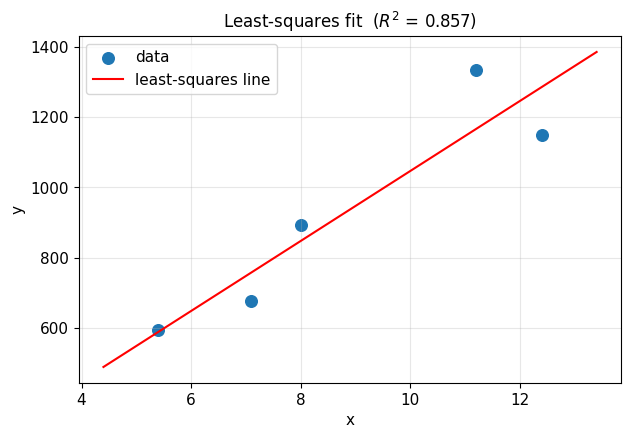

In [29]:
# @title Exercise 6 — Solution
import numpy as np, matplotlib.pyplot as plt
x = np.array([5.4, 7.1, 11.2, 12.4, 8.0])
y = np.array([593, 676, 1335, 1149, 892.0])

X = np.column_stack([np.ones_like(x), x])
theta = np.linalg.solve(X.T @ X, X.T @ y)     # [intercept, slope]
pred = X @ theta
R2 = 1 - np.sum((y - pred)**2) / np.sum((y - y.mean())**2)

print(f"fit:  y = {theta[0]:.2f} + {theta[1]:.2f} x     R^2 = {R2:.4f}")
xs = np.linspace(x.min()-1, x.max()+1, 100)
fig, ax = plt.subplots()
ax.scatter(x, y, s=70, label="data")
ax.plot(xs, theta[0] + theta[1]*xs, "r-", label="least-squares line")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"Least-squares fit  ($R^2$ = {R2:.3f})")
ax.legend(); plt.show()

## Summary — key takeaways

- **Every optimization problem** is a triple: *variables* to choose, an *objective* to
  score them, and *constraints* that fence in the feasible region. Learn to write any
  model in the standard form $\min f(x)$ s.t. $g(x)\le 0,\ h(x)=0$.
- **Convexity is the great divide.** A convex objective over a convex feasible set has
  a *single* optimum that local methods find reliably. Check convexity through the
  **Hessian's eigenvalues**: all $\ge 0$ means convex.
- **Optimality conditions** for unconstrained problems: gradient zero (necessary) plus
  a positive-definite Hessian (sufficient). When you *can* solve $\nabla f = 0$ by
  hand, do — as with the economic lot size and the coin MLE.
- **When you cannot, iterate.** *Steepest descent* uses only the gradient (cheap,
  sometimes slow, prone to zig-zag). *Newton's method* adds the Hessian (fast, exact on
  quadratics, costly per step). *Quasi-Newton / BFGS* approximates the Hessian from
  gradients and is the pragmatic default.
- **Machine learning is applied optimization.** Linear regression is a convex quadratic
  with a closed form; logistic regression is a non-convex classifier trained by the
  same tools.
- **A problem's type — LP, NLP, MILP, MINLP, or under uncertainty — sets its
  difficulty.** Non-convexity and integer variables are what make optimization hard,
  and they are exactly where the rest of CHE 581 is headed.

---

*Module 1 of CHE 581 — Process Optimization. Prepared by Abdulelah S. Alshehri,
Department of Chemical Engineering, King Saud University.*
